# Xenium Prime 5K Breast — V1006 CCC niches

The trained AE, P32/Z32 and H32 are reused. Final K is selected from cell-level program usage without retraining.

In [1]:
from pathlib import Path
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
ROOT = Path('/home/xueshuailin/CCC_Phe/V1006')
SOURCE = ROOT / 'src'
if str(SOURCE) not in sys.path: sys.path.insert(0, str(SOURCE))
from phenoniche.v1006.pipeline import ensure_results
from phenoniche.v1006.data import load_prepared_input
from phenoniche.v1006.reporting import (training_curves, model_selection_plot, spatial_overview,
    niche_celltype_enrichment, spatial_each_niche, niche_size_plot, representative_h_heatmap)
artifacts = ensure_results()
summary, output, selected_K = artifacts['summary'], artifacts['output'], artifacts['selected_K']


## 1. Data and trained model

In [2]:
pd.Series({'cells': summary['n_cells'], 'original CCC features': summary['n_input_features'],
           'retained CCC features': summary['n_retained_features'], 'latent programs': 32,
           'selected final K': selected_K, 'V1002-comparable K': 8}, name='V1006')

cells                    699110
original CCC features       494
retained CCC features       450
latent programs              32
selected final K             13
V1002-comparable K            8
Name: V1006, dtype: int64

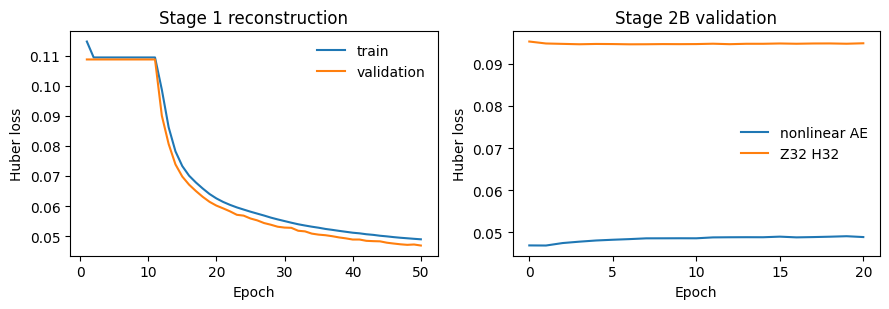

Stage 1 validation reconstruction    0.046899
Stage 2 validation nonlinear AE      0.048881
Stage 2 validation Z32 H32           0.094840
dtype: float64

In [3]:
training_curves(output); plt.show()
pd.Series({'Stage 1 validation reconstruction': summary['stage1_validation_reconstruction'],
           'Stage 2 validation nonlinear AE': summary['stage2_validation_ae'],
           'Stage 2 validation Z32 H32': summary['stage2_validation_linear']})

## 2. Automatic K selection (4–15)

Clustering uses cell-level sqrt(P32) plus log CCC activity. Original Q8_direct is retained as the K=8 comparator.

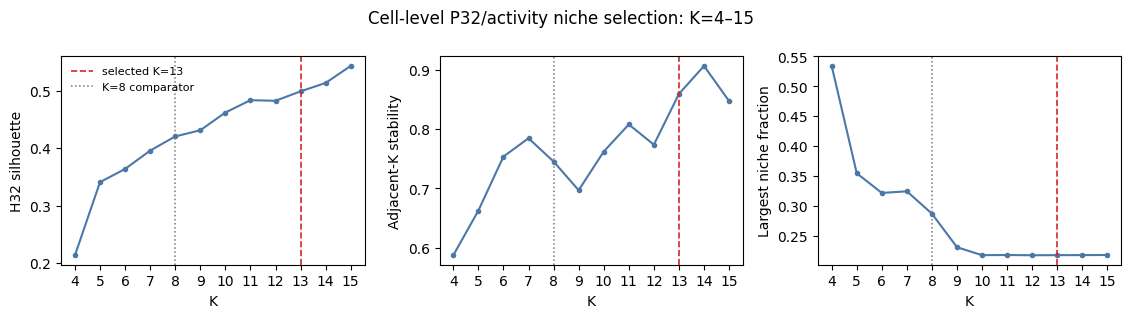

,K,silhouette,adjacent_K_stability,max_niche_cell_fraction,tiny_niche_fraction,mean_assignment_confidence,mean_H_program_separation,selection_score,eligible,selected
0,4,0.2137,0.5872,0.5342,0.0,0.4647,0.7721,0.2500,True,False
1,5,0.3411,0.6626,0.3549,0.0,0.4978,0.8085,0.4958,True,False
2,6,0.3641,0.7538,0.3221,0.0,0.5007,0.8018,0.5918,True,False
3,7,0.3960,0.7846,0.3248,0.0,0.5248,0.8562,0.6616,True,False
4,8,0.4208,0.7453,0.2874,0.0,0.6751,0.8293,0.6245,True,False
5,9,0.4315,0.6969,0.2314,0.0,0.6628,0.9074,0.6731,True,False
6,10,0.4624,0.7622,0.2182,0.0,0.8260,0.9186,0.7454,True,False
7,11,0.4839,0.8080,0.2184,0.0,0.9198,0.9250,0.7823,True,False
8,12,0.4829,0.7738,0.2180,0.0,0.8293,0.9038,0.7220,True,False
9,13,0.4993,0.8595,0.2182,0.0,0.8293,0.9272,0.8026,True,True


Selected K=13: smallest K on the near-optimal cell-latent stability/quality plateau


In [4]:
model_selection_plot(artifacts); plt.show()
columns = ['K','silhouette','adjacent_K_stability','max_niche_cell_fraction',
           'tiny_niche_fraction','mean_assignment_confidence','mean_H_program_separation',
           'selection_score','eligible','selected']
display(artifacts['model_selection'][columns].round(4))
print(f"Selected K={selected_K}: {summary['selection_reason']}")

## 3. Selected-K spatial map

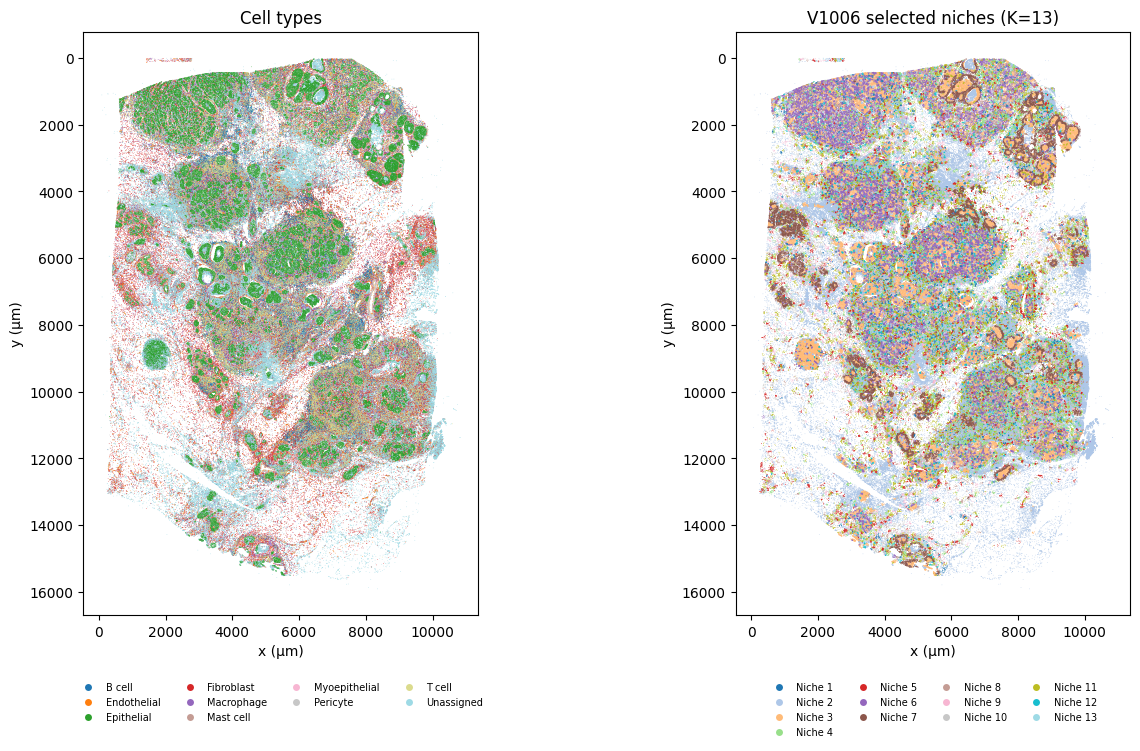

In [5]:
spatial_overview(artifacts); plt.show()

## 4. Niche size and assignment confidence

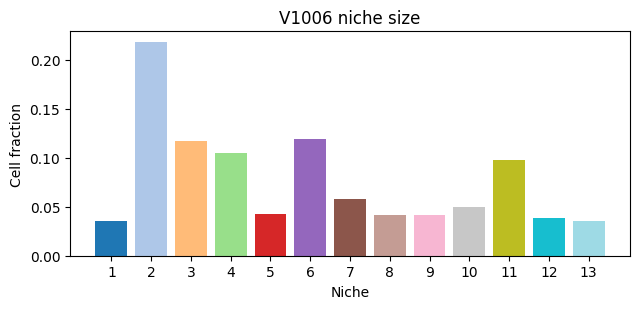

,niche,n_cells,fraction,mean_soft_usage
0,1,24464,0.034993,0.043912
1,2,152556,0.218215,0.210676
2,3,81695,0.116856,0.114098
3,4,73368,0.104945,0.102281
4,5,29962,0.042857,0.045186
5,6,83052,0.118797,0.108816
6,7,40774,0.058323,0.057776
7,8,29337,0.041963,0.046196
8,9,28862,0.041284,0.042187
9,10,34770,0.049735,0.049766


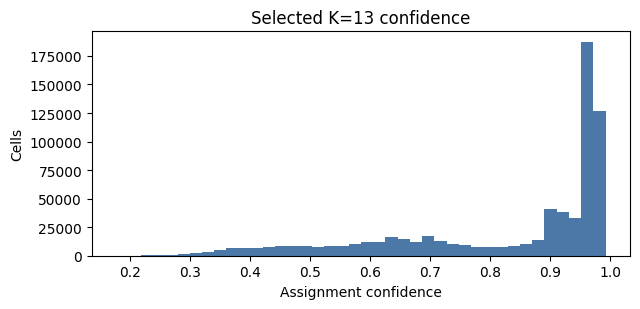

,confidence
count,699110.000000
mean,0.829277
std,0.189126
min,0.177960
10%,0.514291
25%,0.695856
50%,0.930276
75%,0.968717
90%,0.977074
max,0.991977


In [6]:
niche_size_plot(artifacts); plt.show()
display(artifacts['counts'])
confidence = artifacts['assignments']['assignment_confidence_relative']
fig, ax = plt.subplots(figsize=(6.5, 3.2)); ax.hist(confidence, bins=40, color='#4c78a8')
ax.set(xlabel='Assignment confidence', ylabel='Cells', title=f'Selected K={selected_K} confidence')
plt.tight_layout(); plt.show()
pd.Series(confidence).describe(percentiles=[.1,.25,.5,.75,.9]).to_frame('confidence')

## 5. Cell types and individual niche maps

Cell type is used only for post-training interpretation.

/home/xueshuailin/miniconda3/envs/cccphe/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


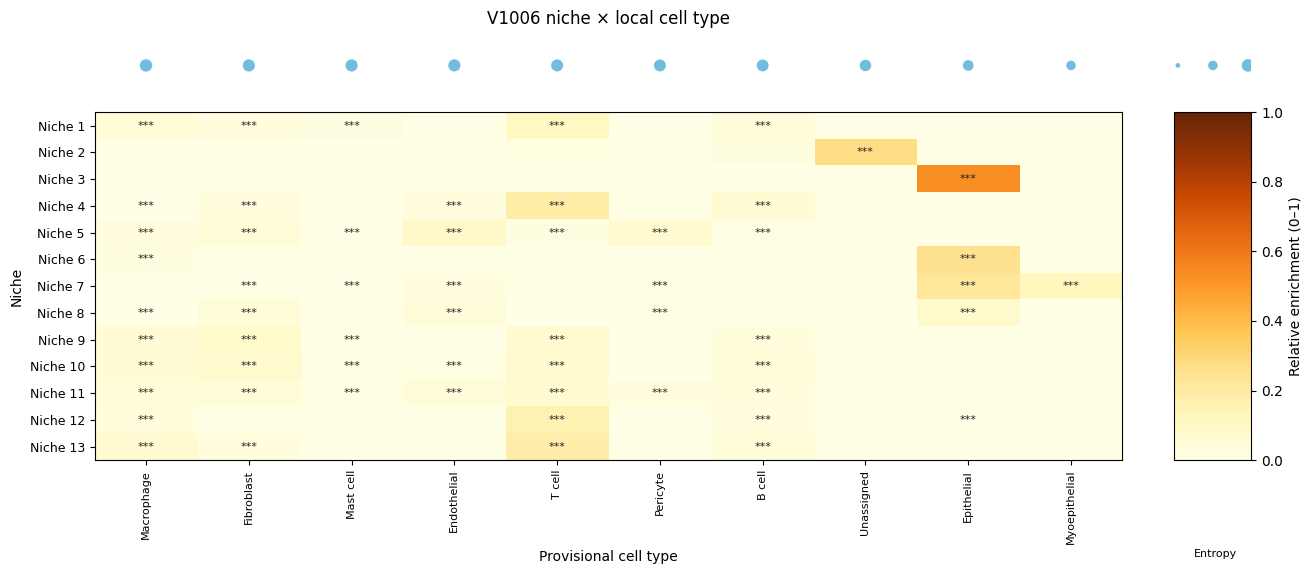

Stars: one-sided Mann–Whitney U; dot size: across-niche entropy.


In [7]:
_, enrichment_table = niche_celltype_enrichment(artifacts); plt.show()
print('Stars: one-sided Mann–Whitney U; dot size: across-niche entropy.')

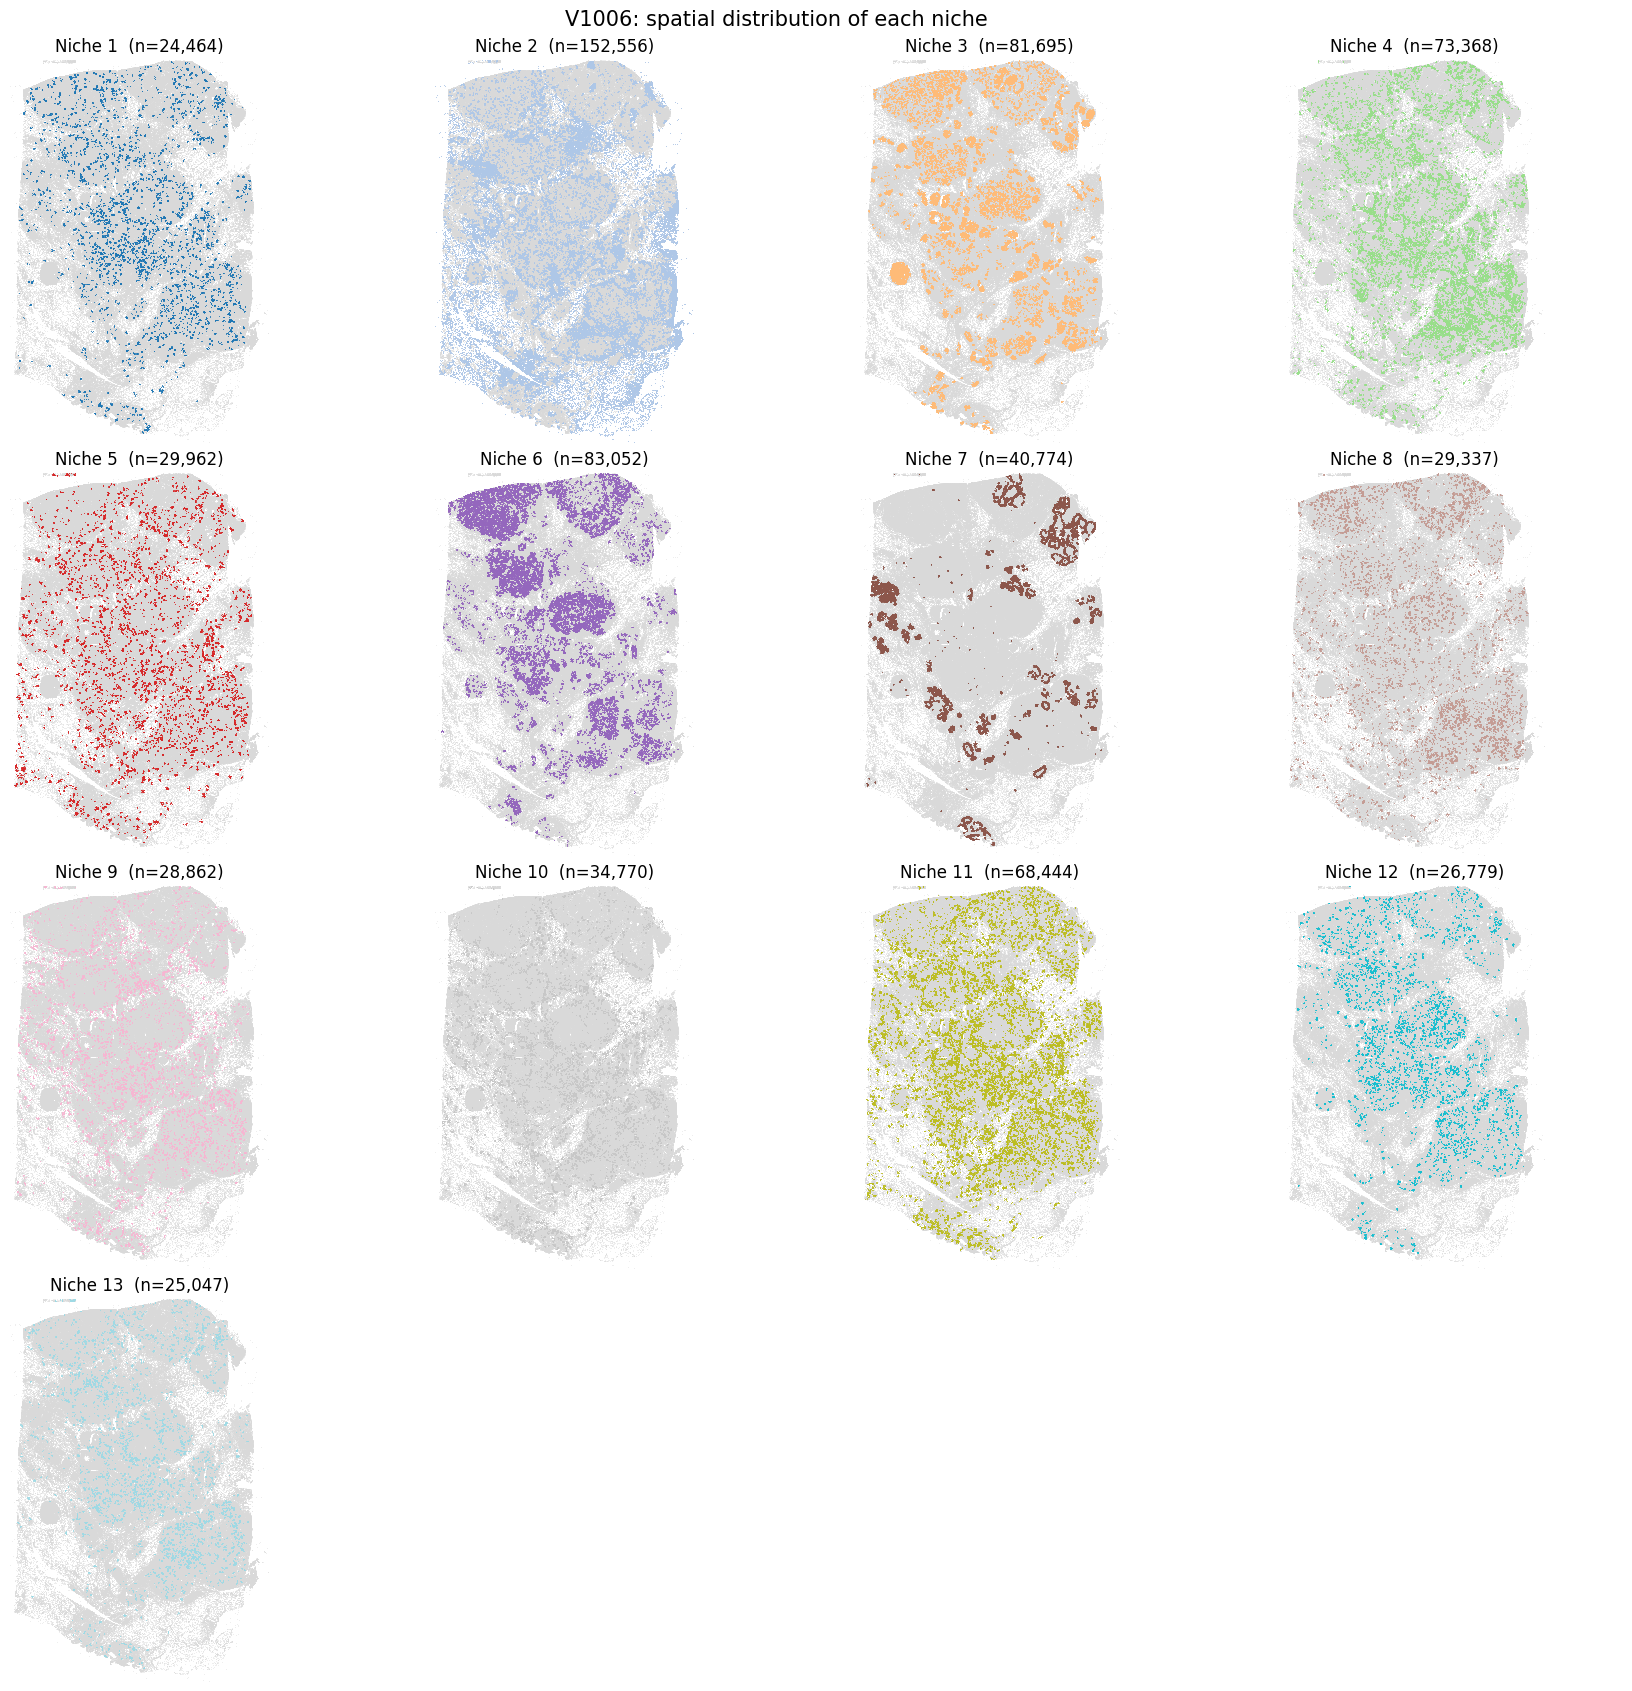

In [8]:
spatial_each_niche(artifacts); plt.show()

## 6. Representative CCC programs

In [9]:
for niche in range(1, selected_K + 1):
    print(f'\nNiche {niche}')
    display(artifacts['top_ccc'].query('niche == @niche')[['rank','ccc','weight']].head(15).reset_index(drop=True))
selected_dir = output / 'selected_model'
print('Top sender → receiver')
display(pd.read_csv(selected_dir/'top_sender_receiver.csv').groupby('niche', group_keys=False).head(5))
print('Top ligand–receptor')
display(pd.read_csv(selected_dir/'top_lr.csv').groupby('niche', group_keys=False).head(5))


Niche 1


,rank,ccc,weight
0,1,Fibroblast → Macrophage | THY1–ITGAX,0.605386
1,2,Epithelial → Mast cell | TIMP3–CD44,0.044022
2,3,Epithelial → Mast cell | PKM–CD44,0.039455
3,4,Mast cell → Epithelial | CD44–EPCAM,0.036941
4,5,Fibroblast → Mast cell | TIMP3–CD44,0.029532
5,6,Epithelial → Mast cell | VEGFA–CD44,0.022505
6,7,Epithelial → Mast cell | TIMP2–CD44,0.016199
7,8,Mast cell → Epithelial | CD44–CLDN7,0.015961
8,9,Endothelial → Mast cell | COL4A1–CD44,0.013897
9,10,Macrophage → Macrophage | CXCL9–FCGR2A,0.006758



Niche 2


,rank,ccc,weight
0,1,Epithelial → Macrophage | TIMP3–CD44,0.087147
1,2,Epithelial → Macrophage | PKM–CD44,0.078128
2,3,Macrophage → Epithelial | CD44–EPCAM,0.072315
3,4,Macrophage → Epithelial | CD44–CLDN7,0.063019
4,5,Epithelial → Macrophage | VEGFA–CD44,0.058303
5,6,Epithelial → Macrophage | TIMP2–CD44,0.057461
6,7,Epithelial → Epithelial | TIMP3–DDR1,0.024658
7,8,Epithelial → Epithelial | TIMP3–CD44,0.021226
8,9,Epithelial → Epithelial | PKM–CD44,0.019071
9,10,Fibroblast → Macrophage | TIMP3–CD44,0.017635



Niche 3


...

,rank,ccc,weight
0,1,Fibroblast → Macrophage | THY1–ITGB2,0.294732
1,2,Macrophage → Fibroblast | ITGB2–THY1,0.294732
2,3,Fibroblast → Macrophage | CCN1–ITGB2,0.141852
3,4,Fibroblast → Macrophage | CCN2–ITGB2,0.137806
4,5,Fibroblast → Macrophage | THY1–ITGAX,0.046375
5,6,Epithelial → Macrophage | F11R–ITGB2,0.034232
6,7,Fibroblast → T cell | TIMP3–CD44,0.011721
7,8,Fibroblast → Macrophage | SERPINE1–PLAUR,0.003406
8,9,Fibroblast → T cell | COL4A1–CD44,0.002873
9,10,Fibroblast → Macrophage | TIMP3–CD44,0.002577


Top sender → receiver


,niche,rank,sender,receiver,weight,sender_receiver
0,1,1,Fibroblast,Macrophage,0.620105,Fibroblast → Macrophage
1,1,2,Epithelial,Mast cell,0.122234,Epithelial → Mast cell
2,1,3,Epithelial,Epithelial,0.063041,Epithelial → Epithelial
3,1,4,Mast cell,Epithelial,0.053283,Mast cell → Epithelial
4,1,5,Fibroblast,Mast cell,0.035530,Fibroblast → Mast cell
...,...,...,...,...,...,...
180,13,1,Fibroblast,Macrophage,0.630110,Fibroblast → Macrophage
181,13,2,Macrophage,Fibroblast,0.294732,Macrophage → Fibroblast
182,13,3,Epithelial,Macrophage,0.034496,Epithelial → Macrophage
183,13,4,Fibroblast,T cell,0.018194,Fibroblast → T cell


Top ligand–receptor


,niche,rank,ligand,receptor,weight,lr
0,1,1,THY1,ITGAX,0.605726,THY1–ITGAX
1,1,2,TIMP3,CD44,0.093937,TIMP3–CD44
2,1,3,PKM,CD44,0.053754,PKM–CD44
3,1,4,CD44,EPCAM,0.040724,CD44–EPCAM
4,1,5,VEGFA,CD44,0.028846,VEGFA–CD44
...,...,...,...,...,...,...
180,13,1,ITGB2,THY1,0.295947,ITGB2–THY1
181,13,2,THY1,ITGB2,0.295947,THY1–ITGB2
182,13,3,CCN1,ITGB2,0.142231,CCN1–ITGB2
183,13,4,CCN2,ITGB2,0.137806,CCN2–ITGB2


## 7. Selected niche × representative CCC heatmap

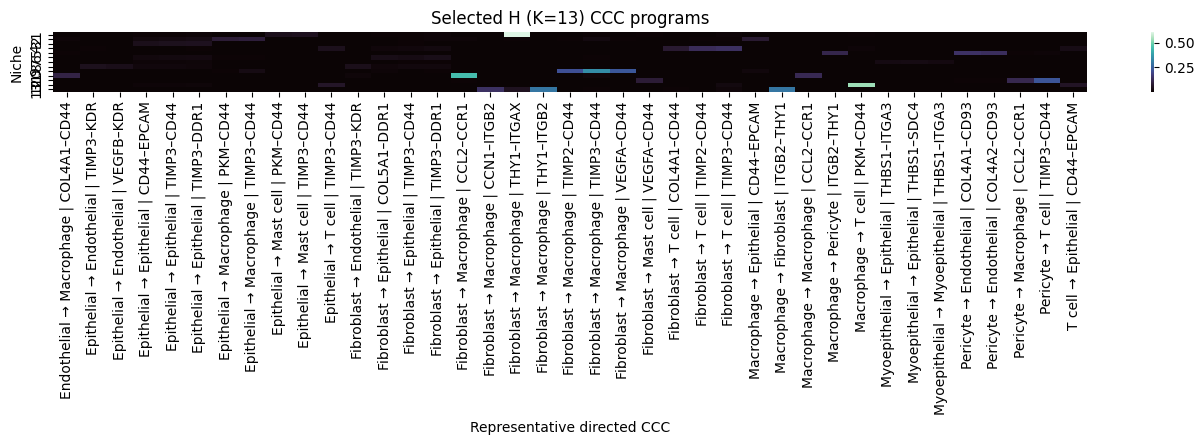

In [10]:
prepared = load_prepared_input(artifacts['config'])
representative_h_heatmap(artifacts['H'], prepared.features); plt.show()

## 8. Latent-program contribution to selected niches

In [11]:
compact = (artifacts['mapping'].groupby('final_niche_id')
           .agg(latent_programs=('program_id', lambda x: ', '.join(map(str, x))),
                total_exposure=('mean_exposure','sum')).reset_index())
display(compact)

,final_niche_id,latent_programs,total_exposure
0,1,"6, 9",0.713678
1,2,1,3.831164
2,3,28,2.156585
3,4,"8, 13",2.078512
4,5,19,0.703026
5,6,"20, 21, 22, 23, 24, 25, 31",2.307498
6,7,"26, 30",1.176565
7,8,10,0.760928
8,9,2,0.818887
9,10,4,0.982787


## 9. Selected K versus original Q8_direct comparator

In [12]:
display(pd.DataFrame({
    'niches': [8, selected_K],
    'largest_niche_fraction': [summary['K8_max_niche_cell_fraction'], summary['selected_max_niche_cell_fraction']],
    'tiny_niche_fraction': [summary['K8_tiny_niche_fraction'], summary['selected_tiny_niche_fraction']],
    'mean_assignment_confidence': [summary['K8_mean_assignment_confidence'], summary['selected_mean_assignment_confidence']]
}, index=['Original Q8_direct', f'Cell-latent selected K={selected_K}']).round(4))

,niches,largest_niche_fraction,tiny_niche_fraction,mean_assignment_confidence
Original Q8_direct,8,0.3151,0.0,0.9138
Cell-latent selected K=13,13,0.2182,0.0,0.8293


## 10. Summary

In [13]:
top = artifacts['top_ccc'].query('rank == 1').set_index('niche')['ccc'].to_dict()
print(f'Selected K: {selected_K}; all selected niches used: {len(artifacts["counts"]) == selected_K and (artifacts["counts"].n_cells > 0).all()}')
print(f'Largest selected niche: {summary["selected_max_niche_cell_fraction"]:.2%}')
print(f'Tiny-niche cell fraction: {summary["selected_tiny_niche_fraction"]:.2%}')
print(f'Mean assignment confidence: {summary["selected_mean_assignment_confidence"]:.3f}')
display(pd.Series(top, name='Top representative CCC').rename_axis('Niche').to_frame())

Selected K: 13; all selected niches used: True
Largest selected niche: 21.82%
Tiny-niche cell fraction: 0.00%
Mean assignment confidence: 0.829


,Top representative CCC
Niche,
1,Fibroblast → Macrophage | THY1–ITGAX
2,Epithelial → Macrophage | TIMP3–CD44
3,Epithelial → Epithelial | TIMP3–DDR1
4,Fibroblast → T cell | TIMP3–CD44
5,Pericyte → Endothelial | COL4A1–CD93
6,Fibroblast → Epithelial | TIMP3–DDR1
7,Myoepithelial → Epithelial | THBS1–SDC4
8,Epithelial → Endothelial | TIMP3–KDR
9,Fibroblast → Macrophage | TIMP3–CD44
